A learning/visualization tool to experiment with Random Forest parameters interactively.

Helps understand how parameters like n_estimators, max_depth, and features affect performance.

In [45]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

In [46]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [47]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.267257,0.858660,1.151604,-1.665468,0.140886,0
1,-0.169850,-1.375141,-0.334387,-0.391207,0.894956,1
2,1.337809,1.332697,-1.512343,-0.193447,-1.068442,1
3,-2.848378,-0.235143,-2.509766,-0.958869,-1.808537,1
4,2.181325,0.839499,-0.373014,-1.801861,-0.487899,1


In [48]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [49]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols].copy()
  new_df['target'] = df['target']
  return new_df

In [50]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df, row_percent).copy()
  return sample_features(new_df,col_percent)

In [51]:
df1 = combined_sampling(df,0.5,0.5)

In [52]:
df2 = combined_sampling(df,0.5,0.5)

In [53]:
df3 = combined_sampling(df,0.5,0.5)

In [54]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col3', 'col5', 'target'], dtype='object')
Index(['col3', 'col5', 'target'], dtype='object')
Index(['col4', 'col5', 'target'], dtype='object')


In [55]:
df3

,col4,col5,target
2,-0.193447,-1.068442,1
73,-0.235564,-0.429614,1
95,1.935585,-0.765535,0
50,-1.364595,-0.000297,1
79,-1.685042,0.926674,0
91,-2.196828,-1.800884,1
49,-3.861591,0.337795,0
14,0.886449,-1.344793,1
96,-3.496643,-1.840917,0
35,0.118471,0.503232,0


In [56]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [57]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

In [58]:
from sklearn.tree import plot_tree

[Text(0.6, 0.875, 'x[0] <= 0.246\ngini = 0.471\nsamples = 50\nvalue = [19, 31]'),
 Text(0.4, 0.625, 'x[0] <= -0.119\ngini = 0.114\nsamples = 33\nvalue = [2, 31]'),
 Text(0.5, 0.75, 'True  '),
 Text(0.2, 0.375, 'gini = 0.0\nsamples = 26\nvalue = [0, 26]'),
 Text(0.6, 0.375, 'x[1] <= -0.809\ngini = 0.408\nsamples = 7\nvalue = [2, 5]'),
 Text(0.4, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.8, 0.125, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.8, 0.625, 'gini = 0.0\nsamples = 17\nvalue = [17, 0]'),
 Text(0.7, 0.75, '  False')]

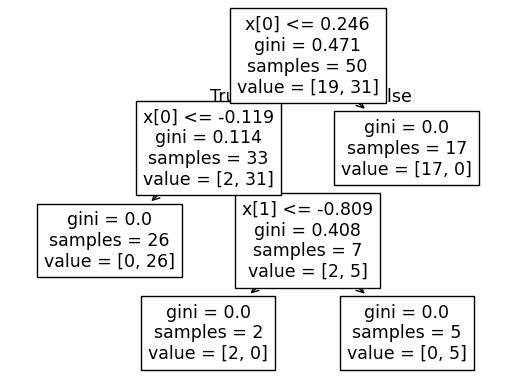

In [59]:
plot_tree(clf1)

[Text(0.4444444444444444, 0.875, 'x[0] <= 0.065\ngini = 0.499\nsamples = 50\nvalue = [26, 24]'),
 Text(0.2222222222222222, 0.625, 'x[0] <= -0.122\ngini = 0.08\nsamples = 24\nvalue = [1, 23]'),
 Text(0.3333333333333333, 0.75, 'True  '),
 Text(0.1111111111111111, 0.375, 'gini = 0.0\nsamples = 21\nvalue = [0, 21]'),
 Text(0.3333333333333333, 0.375, 'x[1] <= -0.822\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.2222222222222222, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4444444444444444, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.6666666666666666, 0.625, 'x[1] <= 0.536\ngini = 0.074\nsamples = 26\nvalue = [25, 1]'),
 Text(0.5555555555555556, 0.75, '  False'),
 Text(0.5555555555555556, 0.375, 'gini = 0.0\nsamples = 22\nvalue = [22, 0]'),
 Text(0.7777777777777778, 0.375, 'x[1] <= 0.82\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.6666666666666666, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8888888888888888, 0.125, 'gini = 0.0\ns

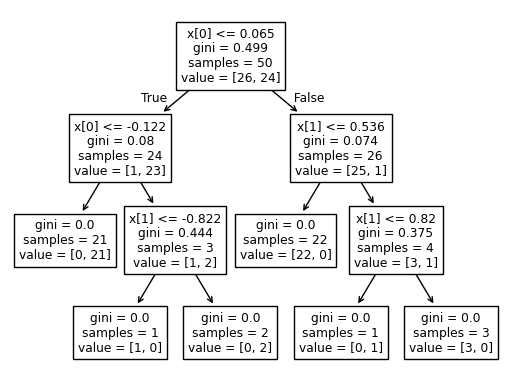

In [60]:
plot_tree(clf2)

[Text(0.32142857142857145, 0.9285714285714286, 'x[0] <= -2.375\ngini = 0.497\nsamples = 50\nvalue = [23, 27]'),
 Text(0.09523809523809523, 0.7857142857142857, 'x[1] <= -0.524\ngini = 0.245\nsamples = 7\nvalue = [6, 1]'),
 Text(0.20833333333333334, 0.8571428571428572, 'True  '),
 Text(0.047619047619047616, 0.6428571428571429, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.14285714285714285, 0.6428571428571429, 'x[1] <= -0.088\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.09523809523809523, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.19047619047619047, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.5476190476190477, 0.7857142857142857, 'x[0] <= -0.081\ngini = 0.478\nsamples = 43\nvalue = [17, 26]'),
 Text(0.43452380952380953, 0.8571428571428572, '  False'),
 Text(0.38095238095238093, 0.6428571428571429, 'x[1] <= 0.882\ngini = 0.375\nsamples = 28\nvalue = [7, 21]'),
 Text(0.2857142857142857, 0.5, 'x[0] <= -1.081\ngini = 0.287\nsamples = 23\nvalue = [4, 19

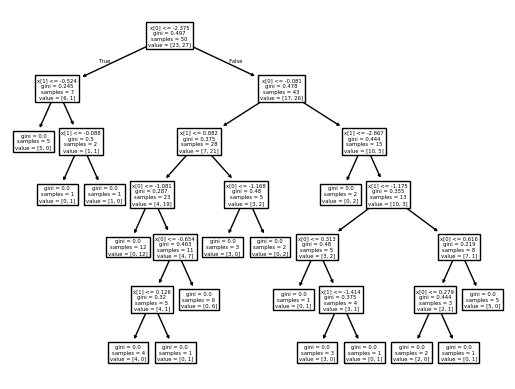

In [61]:
plot_tree(clf3)

In [ ]:
clf1.predict(pd.DataFrame([[-1.042498, -0.064323]], columns=clf1.feature_names_in_))

['col3' 'col5']


array([1])

In [71]:
clf2.predict(pd.DataFrame([[-1.042498,	-0.064323]], columns=clf2.feature_names_in_))

array([1])

In [72]:
clf3.predict(pd.DataFrame([[-1.042498,	-0.064323]], columns=clf3.feature_names_in_))

array([0])

In [73]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
88,1.633961,0.827115,0.689790,0.792555,-0.691229,0
79,3.120412,-0.176764,2.350363,-1.685042,0.926674,0
63,2.341005,0.732960,1.628280,1.410234,1.055427,0
5,3.580357,0.558491,-0.619950,-2.565839,-0.750393,1
40,-1.318122,-1.963927,-0.473878,-1.010092,0.882085,1
54,0.319783,-0.453708,0.850172,-4.177152,-0.205770,1
84,3.225625,2.602196,-2.709262,-0.870201,-2.654873,1
10,-3.019586,2.645800,-2.859041,1.020608,-3.197431,1
1,-0.169850,-1.375141,-0.334387,-0.391207,0.894956,1
3,-2.848378,-0.235143,-2.509766,-0.958869,-1.808537,1
